In [2]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import pytidycensus as tc
from os import getenv
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
from pygris import tracts

import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from utils import collect_ruca_data, CensusConfig, BaseCensusDataLoader

load_dotenv()

API_KEY: str = getenv("CENSUS_KEY")

tc.set_census_api_key(API_KEY)



Census API key has been set for this session.


# RUCA Codes



|Code|Classification description|
|---|---|
|1|Metropolitan core: primary flow is within an urban area of 50,000 or more people (metro UA)|
|2|Metropolitan high commuting: primary flow is 30 percent or more to a metro UA|
|3|Metropolitan low commuting: primary flow is 10 percent to 30 percent to a metro UA|
|4|Micropolitan core: primary flow is within an urban area of 10,000 to 49,999 people (micro UA)|
|5|Micropolitan high commuting: primary flow is 30 percent or more to a micro UA|
|6|Micropolitan low commuting: primary flow is 10 percent to 30 percent to a micro UA|
|7|Small town core: primary flow is within an urban area of 9,999 or fewer people (small town UA)|
|8|Small town high commuting: primary flow is 30 percent or more to a small town UA|
|9|Small town low commuting: primary flow is 10 percent to 30 percent to a small town UA|
|10|Rural area: primary flow is to a tract outside an UA|
|99|Not coded: census tract is entirely in coastal or inland water bodies, with zero population and zero land area|

See the [RUCA Codes](https://www.ers.usda.gov/data-products/rural-urban-commuting-area-codes/documentation) documentation for detailed info on data and methods used for creating RUCA Codes.

In [3]:
if "ruca" not in locals():
    ruca = collect_ruca_data()
ruca.head()


Total # of census tracts: 85528
# of continental census tracts: 83776


,TractFIPS,TractName,CountyFIPS,CountyName,StateFIPS,StateName,RUCA
0,01001020100,Census Tract 201,01001,Autauga County,01,Alabama,1
1,01001020200,Census Tract 202,01001,Autauga County,01,Alabama,1
2,01001020300,Census Tract 203,01001,Autauga County,01,Alabama,1
3,01001020400,Census Tract 204,01001,Autauga County,01,Alabama,1
4,01001020501,Census Tract 205.01,01001,Autauga County,01,Alabama,1


In [4]:
STATES = list(ruca["StateFIPS"].unique())  # List of states to pass to pytidycensus
YEAR: int = 2024


In [ ]:
config = CensusConfig(year=YEAR, states=STATES, api_key=API_KEY)
loader = BaseCensusDataLoader(config)

# Combine all 39 variables
all_vars = [
    # Rent
    "B25070_001E", "B25070_007E", "B25070_008E", "B25070_009E", "B25070_010E",
    # Owner
    "B25091_001E", "B25091_008E", "B25091_009E", "B25091_010E", "B25091_011E",
    "B25091_019E", "B25091_020E", "B25091_021E", "B25091_022E",
    # Poverty
    "B17001_001E", "B17001_002E",
    # Housing Quality
    "B25047_001E", "B25047_003E", "B25051_001E", "B25051_003E",
    # Demographics
    "B03002_001E", "B03002_003E",
    # Gini
    "B19083_001E"
] + [f"B15003_{num:03d}E" for num in range(2, 17)]

if "raw_acs" not in locals():
    raw_acs = loader.fetch(all_vars)


In [5]:
ruca_counts = {
    "Count": ruca["RUCA"].value_counts().sort_index(),
    "Proportion": round(
        ruca["RUCA"].value_counts(normalize=True).sort_index() * 100, 2
    ),
}
pd.DataFrame(ruca_counts)


,Count,Proportion
RUCA,,
1,57544,68.69
2,8481,10.12
3,1149,1.37
4,4630,5.53
5,2224,2.65
6,693,0.83
7,1475,1.76
8,607,0.72
9,336,0.40


# ACS Data

## Cost Burden

Collects variables for housing cost burden (renters and owners spending 30% or more of household income on housing) to measure overall cost burden.


In [5]:
#| output: false
rent_burden_vars = [
    "B25070_001E",  # Total (Renter)
    "B25070_007E",  # Gross rent: 30.0 to 34.9 percent
    "B25070_008E",  # Gross rent: 35.0 to 39.9 percent
    "B25070_009E",  # Gross rent: 40.0 to 49.9 percent
    "B25070_010E",  # Gross rent: 50.0 percent or more
]

owner_burden_vars = [
    "B25091_001E",  # Total (Owner)
    "B25091_008E",  # Housing units with a mortgage: 30.0 to 34.9 percent
    "B25091_009E",  # Housing units with a mortgage: 35.0 to 39.9 percent
    "B25091_010E",  # Housing units with a mortgage: 40.0 to 49.9 percent
    "B25091_011E",  # Housing units with a mortgage: 50.0 percent or more
    "B25091_019E",  # Housing units without a mortgage: 30.0 to 34.9 percent
    "B25091_020E",  # Housing units without a mortgage: 35.0 to 39.9 percent
    "B25091_021E",  # Housing units without a mortgage: 40.0 to 49.9 percent
    "B25091_022E",  # Housing units without a mortgage: 50.0 percent or more
]

cost_burden_vars = rent_burden_vars + owner_burden_vars

var_table_rent = tc.get_table_variables("B25070", 2024, "acs", "acs5")
var_table_owner = tc.get_table_variables("B25091", 2024, "acs", "acs5")
var_table = pd.concat([var_table_rent, var_table_owner])
var_table = var_table.loc[var_table["name"].isin(cost_burden_vars)]
var_table["label"] = var_table["label"].str.replace("Estimate", "")
var_table["label"] = var_table["label"].str.replace("Total", "")
var_table["label"] = var_table["label"].str.replace("!!", "")

# var_table


Loaded cached variables for 2024 acs acs5
Loaded cached variables for 2024 acs acs5


In [6]:
if "cost_burden" not in locals():
    cost_burden = raw_acs.copy()

    # Filter out tracts with zero total units (both renter and owner units are zero)
    total_units = cost_burden["B25070_001E"] + cost_burden["B25091_001E"]
    # cost_burden = cost_burden.loc[total_units != 0].dropna(axis=0)

    # Re-evaluate total_units after filtering
    total_units = cost_burden["B25070_001E"] + cost_burden["B25091_001E"]

    # Compute combined cost burden
    burdened_renters = cost_burden[rent_burden_vars[1::]].sum(axis=1)
    burdened_owners = cost_burden[owner_burden_vars[1::]].sum(axis=1)
    cost_burden["CostBurden"] = (burdened_renters + burdened_owners) / total_units

    cost_burden = cost_burden[["GEOID", "CostBurden"]]

cost_burden.head()


Getting data from the 2020-2024 5-year ACS


,GEOID,CostBurden
0,01001020100,0.168478
1,01001020200,0.163851
2,01001020300,0.235628
3,01001020400,0.142857
4,01001020501,0.189303


## Poverty Rate


Calculates poverty rate based on the number of people with income below the poverty level in 12 months and divides it by the population.

In [7]:
#| output: false
poverty_vars = [
    "B17001_001E",  # Total
    "B17001_002E",  # Income in the past 12 months below poverty level
]

var_table = tc.get_table_variables("B17001", 2024, "acs", "acs5")
var_table = var_table.loc[var_table["name"].isin(poverty_vars)]
var_table["label"] = var_table["label"].str.replace("Estimate", "")
var_table["label"] = var_table["label"].str.replace("Total", "")
var_table["label"] = var_table["label"].str.replace("!!", "")

# var_table


Loaded cached variables for 2024 acs acs5


In [8]:
if "poverty" not in locals():
    poverty = raw_acs.copy()

    poverty["PovertyRate"] = poverty[poverty_vars[1]] / poverty[poverty_vars[0]]
    poverty = poverty[["GEOID", "PovertyRate"]]

poverty.head()


Getting data from the 2020-2024 5-year ACS


,GEOID,PovertyRate
0,01001020100,0.174060
1,01001020200,0.095051
2,01001020300,0.071387
3,01001020400,0.153495
4,01001020501,0.035104


## Housing Quality

Collects variables for substandard plumbing and kitchen facilities to measure overall housing quality.


In [9]:
#| output: false
housing_quality_vars = [
    "B25047_001E",  # Total units (Plumbing)
    "B25047_003E",  # Lacking complete plumbing facilities
    "B25051_001E",  # Total units (Kitchen)
    "B25051_003E",  # Lacking complete kitchen facilities
]

# Fetch metadata for both tables and concatenate them
var_table_plumbing = tc.get_table_variables("B25047", 2024, "acs", "acs5")
var_table_kitchen = tc.get_table_variables("B25051", 2024, "acs", "acs5")
var_table = pd.concat([var_table_plumbing, var_table_kitchen])
var_table = var_table.loc[var_table["name"].isin(housing_quality_vars)]
var_table["label"] = var_table["label"].str.replace("Estimate", "")
var_table["label"] = var_table["label"].str.replace("Total", "")
var_table["label"] = var_table["label"].str.replace("!!", "")

# var_table


Loaded cached variables for 2024 acs acs5
Loaded cached variables for 2024 acs acs5


In [10]:
if "housing_quality" not in locals():
    housing_quality = raw_acs.copy()

    # Filter out tracts with zero total units and compute index
    # housing_quality = housing_quality.loc[housing_quality[housing_quality_vars[0]] != 0].dropna(axis=0)
    housing_quality["HousingQuality"] = (
        housing_quality["B25047_003E"] + housing_quality["B25051_003E"]
    ) / housing_quality["B25047_001E"]

    housing_quality = housing_quality[["GEOID", "HousingQuality"]]

housing_quality.head()


Getting data from the 2020-2024 5-year ACS


,GEOID,HousingQuality
0,01001020100,0.007916
1,01001020200,0.100287
2,01001020300,0.092125
3,01001020400,0.008419
4,01001020501,0.000000


## Education



Calculates percentage of the population that does not hold a high school diploma

In [11]:
#| output: false
education_vars = [
    "B15003_001E",  # Total (Population 25 years and over)
] + [f"B15003_{num:03d}E" for num in range(2, 17)]

var_table = tc.get_table_variables("B15003", 2024, "acs", "acs5")
var_table = var_table.loc[var_table["name"].isin(education_vars)]
var_table["label"] = var_table["label"].str.replace("Estimate", "")
var_table["label"] = var_table["label"].str.replace("Total", "")
var_table["label"] = var_table["label"].str.replace("!!", "")

# var_table


Loaded cached variables for 2024 acs acs5


In [12]:
if "education" not in locals():
    education = raw_acs.copy()

    # education = education.loc[education[education_vars[0]] != 0].dropna(axis=0)
    education["LessThanHS"] = (
        education[education_vars[1::]].sum(axis=1) / education[education_vars[0]]
    )
    education = education[["GEOID", "LessThanHS"]]

education.head()


Getting data from the 2020-2024 5-year ACS


,GEOID,LessThanHS
0,01001020100,0.094197
1,01001020200,0.097473
2,01001020300,0.130983
3,01001020400,0.053578
4,01001020501,0.031766


## Demographics


In [13]:
#| output: false
demographics_vars = [
    "B03002_001E",  # Total
    "B03002_003E",  # Not Hispanic or Latino: White alone
]

var_table = tc.get_table_variables("B03002", 2024, "acs", "acs5")
var_table = var_table.loc[var_table["name"].isin(demographics_vars)]
var_table["label"] = var_table["label"].str.replace("Estimate", "")
var_table["label"] = var_table["label"].str.replace("Total", "")
var_table["label"] = var_table["label"].str.replace("!!", "")

# var_table


Loaded cached variables for 2024 acs acs5


In [14]:
if "demographics" not in locals():
    demographics = raw_acs.copy()

    # demographics = demographics.loc[demographics[demographics_vars[0]] != 0].dropna(axis=0)
    demographics["PercentMinority"] = 1 - (
        demographics[demographics_vars[1]] / demographics[demographics_vars[0]]
    )
    demographics = demographics[["GEOID", "PercentMinority"]]

demographics.head()


Getting data from the 2020-2024 5-year ACS


,GEOID,PercentMinority
0,01001020100,0.334643
1,01001020200,0.676971
2,01001020300,0.358540
3,01001020400,0.119048
4,01001020501,0.215122


## Household Vars

In [15]:
misc_vars = {
    "Gini": "B19083_001E",
}

if "misc" not in locals():
    misc = raw_acs.copy()


misc = misc[["GEOID", "Gini"]]
misc.head()


Getting data from the 2020-2024 5-year ACS


,GEOID,Gini
0,01001020100,0.4238
1,01001020200,0.4100
2,01001020300,0.3519
3,01001020400,0.5880
4,01001020501,0.3954


# Data Analysis


Merge all individual ACS socioeconomic indicators and combines them with the cleaned RUCA dataset by Census Tract GEOID.


In [16]:
if "DATA" not in locals():
    # List of collected ACS dataframes
    collected_dfs = [
        poverty,
        cost_burden,
        housing_quality,
        education,
        demographics,
        misc,
    ]

    acs_merged = collected_dfs[0]
    for df in collected_dfs[1:]:
        acs_merged = pd.merge(acs_merged, df, on="GEOID", how="outer")

    print(f"Total ACS tracts merged: {len(acs_merged)}")

    DATA = pd.merge(
        ruca, acs_merged, left_on="TractFIPS", right_on="GEOID", how="inner"
    )

    print(f"Final tract count: {len(DATA)}")

DATA.head()


Total ACS tracts merged: 83763
Final tract count: 82879


,TractFIPS,TractName,CountyFIPS,CountyName,StateFIPS,StateName,RUCA,GEOID,PovertyRate,CostBurden,HousingQuality,LessThanHS,PercentMinority,Gini
0,01001020100,Census Tract 201,01001,Autauga County,01,Alabama,1,01001020100,0.174060,0.168478,0.007916,0.094197,0.334643,0.4238
1,01001020200,Census Tract 202,01001,Autauga County,01,Alabama,1,01001020200,0.095051,0.163851,0.100287,0.097473,0.676971,0.4100
2,01001020300,Census Tract 203,01001,Autauga County,01,Alabama,1,01001020300,0.071387,0.235628,0.092125,0.130983,0.358540,0.3519
3,01001020400,Census Tract 204,01001,Autauga County,01,Alabama,1,01001020400,0.153495,0.142857,0.008419,0.053578,0.119048,0.5880
4,01001020501,Census Tract 205.01,01001,Autauga County,01,Alabama,1,01001020501,0.035104,0.189303,0.000000,0.031766,0.215122,0.3954


In [17]:
df = DATA.replace([np.inf, -np.inf], np.nan).dropna()

len(DATA), len(df)


(82879, 81802)

## Descriptive Statistics

In [18]:
df.describe()


,RUCA,PovertyRate,CostBurden,HousingQuality,LessThanHS,PercentMinority,Gini
count,81802.000000,81802.000000,81802.000000,81802.000000,81802.000000,81802.000000,81802.000000
mean,2.314088,0.135813,0.312121,0.044292,0.109586,0.416713,0.423781
std,2.628321,0.108560,0.125279,0.069683,0.096994,0.291475,0.067424
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000100
25%,1.000000,0.058684,0.217634,0.000000,0.041479,0.165269,0.378300
50%,1.000000,0.106323,0.294195,0.020309,0.081125,0.346462,0.417900
75%,2.000000,0.180921,0.391065,0.058467,0.147231,0.640236,0.463000
max,10.000000,1.000000,1.000000,1.307692,0.800313,1.000000,0.826000


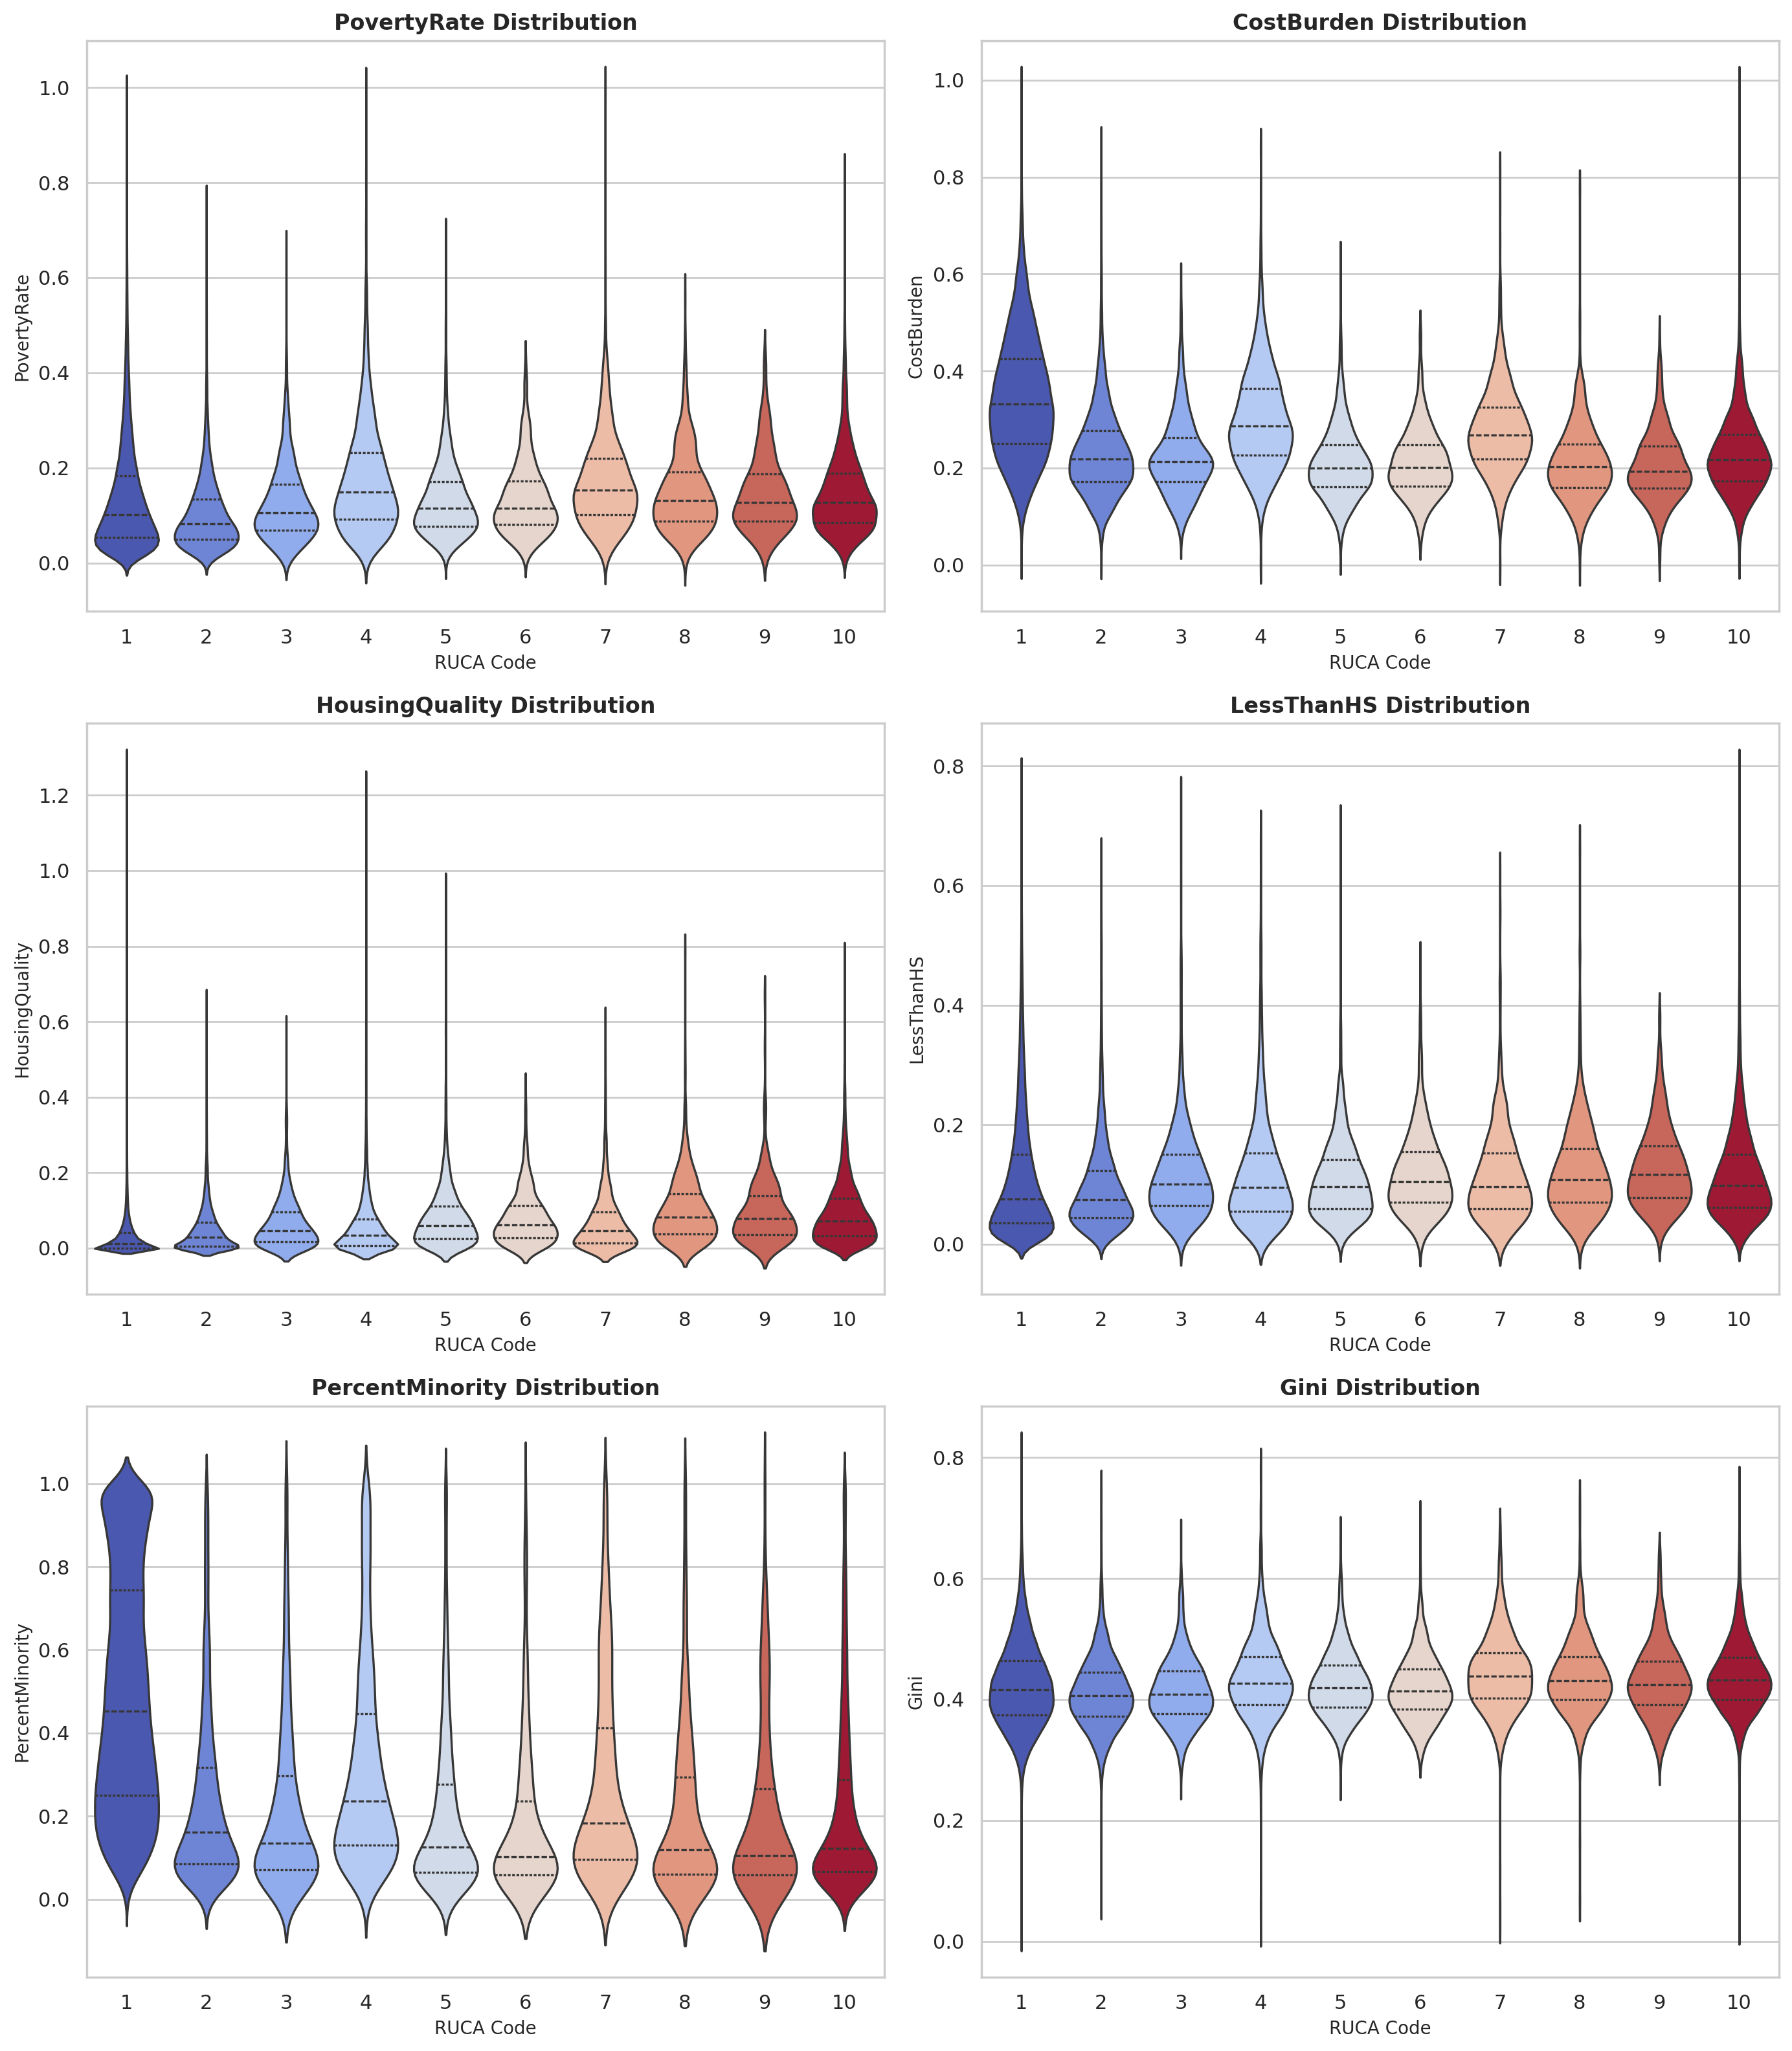

In [19]:
# Set academic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 16), dpi=200)
axes = axes.flatten()

features = [
    "PovertyRate",
    "CostBurden",
    "HousingQuality",
    "LessThanHS",
    "PercentMinority",
    "Gini",
]
colors = sns.color_palette("muted", len(features))

for idx, (feature, ax) in enumerate(zip(features, axes)):
    sns.violinplot(
        x="RUCA",
        y=feature,
        data=df,
        ax=ax,
        palette="coolwarm",
        hue="RUCA",
        legend=False,
        inner="quartile",
        linewidth=1.2,
    )
    ax.set_title(f"{feature} Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel("RUCA Code", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)

plt.tight_layout()
plt.savefig("ruca_violin_panel.png", bbox_inches="tight")
plt.show()


Inner lines show 25%, 50% (median), and 75% interquartile ranges. wider parts -> more tracts within value range, skinny parts -> fewer tracts within value range
x axis = variable as a percentage of the population

## Pearson Correlation Matrix

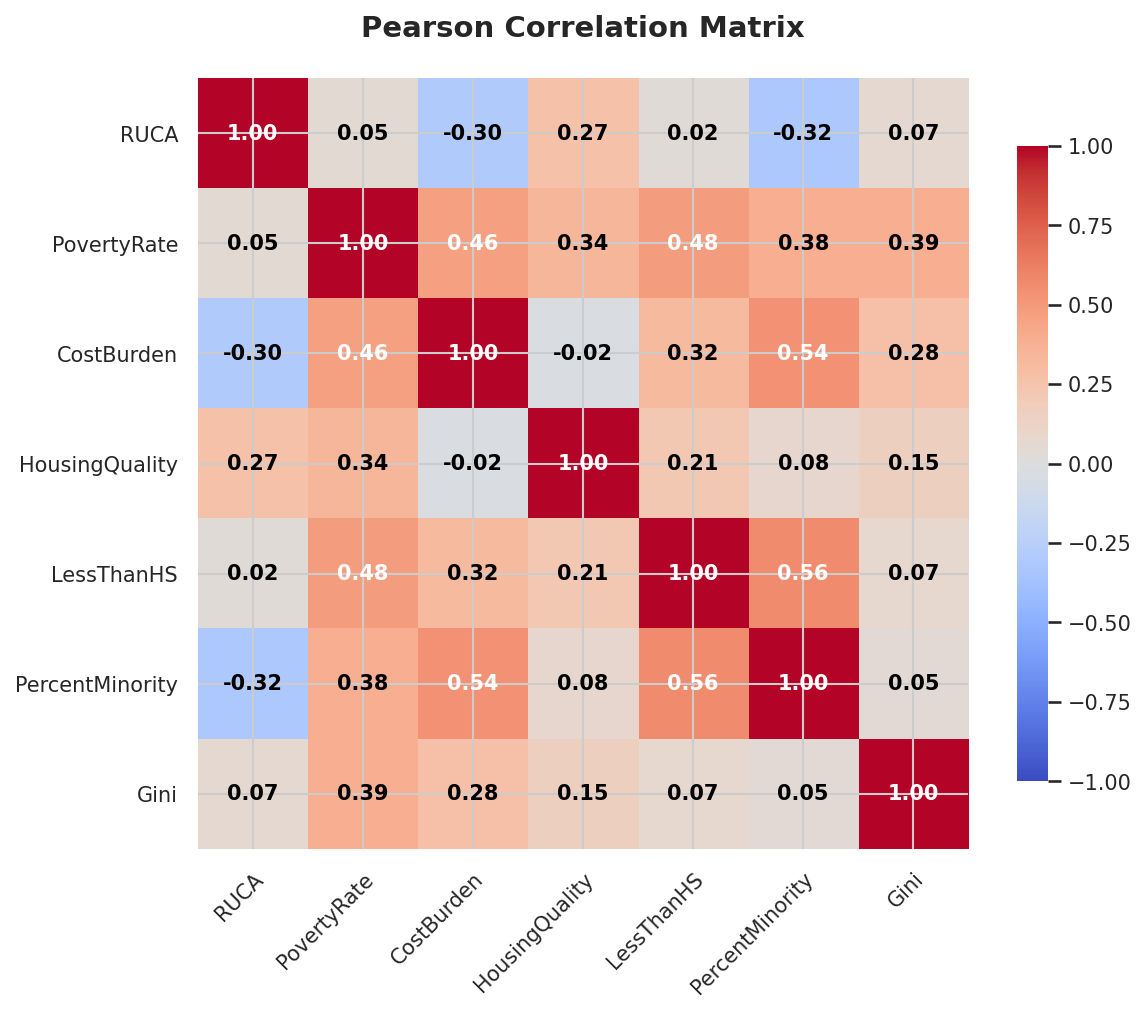

In [20]:
# Select numerical columns of interest
numerical_cols = [
    "RUCA",
    "PovertyRate",
    "CostBurden",
    "HousingQuality",
    "LessThanHS",
    "PercentMinority",
    "Gini",
]
corr_matrix = DATA[numerical_cols].dropna(axis=0).corr(method="pearson")

# Plot setup
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax, shrink=0.75, pad=0.05)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)

# Show ticks and labels
ax.set_xticks(np.arange(len(numerical_cols)))
ax.set_yticks(np.arange(len(numerical_cols)))
ax.set_xticklabels(
    numerical_cols, rotation=45, ha="right", rotation_mode="anchor", fontsize=10
)
ax.set_yticklabels(numerical_cols, fontsize=10)

# Hide the spines
for edge in ["top", "right", "bottom", "left"]:
    ax.spines[edge].set_visible(False)

# Loop over data dimensions and create text annotations
for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        val = corr_matrix.iloc[i, j]
        # Choose text color based on cell color (contrast)
        color = "white" if abs(val) > 0.4 else "black"
        text = ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=color,
            fontsize=10,
            weight="bold",
        )

# Title and layout
ax.set_title("Pearson Correlation Matrix", fontsize=14, weight="bold", pad=20)
fig.tight_layout()
plt.show()


- The minority percentage and cost burden percentage of a census tract decreases as census tracts become more urban whereas poor housing quality go's up.
- LessThanHS has decent postive correlations (0.3 - 0.5) with PovertyRate and PercentMinority

## Variable Inflation Factor

In [21]:
# Keep only numeric columns (excluding the target RUCA variable)
vif_features = [
    "PovertyRate",
    "CostBurden",
    "HousingQuality",
    "LessThanHS",
    "PercentMinority",
    "Gini",
]

df_vif = df[vif_features].astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i) for i in range(len(df_vif.columns))
]
vif_data


,feature,VIF
0,PovertyRate,4.343494
1,CostBurden,12.310752
2,HousingQuality,1.680772
3,LessThanHS,3.834566
4,PercentMinority,5.660608
5,Gini,8.526785


- [VIF Interpretation](https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/)
  - VIF ≈ 1: No correlation with other predictors
  - 1 < VIF ≤ 5: Mild to moderate correlation (usually fine)
  - VIF > 10: Strong multicollinearity -> take corrective steps

CostBurden and Percent Minority are over 5 but less than 6, so I don't think they'll cause significant multicolinearity issues.

At 8.5 the Gini coefficient is close to being problematic. Since it's the main way the ACS measures income inequality, so unless it causes problems down the road I guess it's fine ¯\\_(ツ)_/¯



## Multinomial Logistic Regression

In [22]:
X = df[
    [
        "PovertyRate",
        "CostBurden",
        "HousingQuality",
        "LessThanHS",
        "PercentMinority",
        "Gini",
    ]
].astype(float)
X = sm.add_constant(X)
y = df["RUCA"].astype(int)

# Fit the model
model = sm.MNLogit(y, X)
result = model.fit(method="bfgs", maxiter=1000)

# Display the results
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.931436
         Iterations: 375
         Function evaluations: 377
         Gradient evaluations: 377
                          MNLogit Regression Results                          
Dep. Variable:                   RUCA   No. Observations:                81802
Model:                        MNLogit   Df Residuals:                    81739
Method:                           MLE   Df Model:                           54
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                  0.2071
Time:                        18:09:39   Log-Likelihood:                -76193.
converged:                       True   LL-Null:                       -96090.
Covariance Type:            nonrobust   LLR p-value:                     0.000
         RUCA=2       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.763

Pretty much all of the coefficients are statistically significant but considering the large number of observations and the very low amount of variation between values, I don't think it really means much beyond being able to say they're statistically significant. 

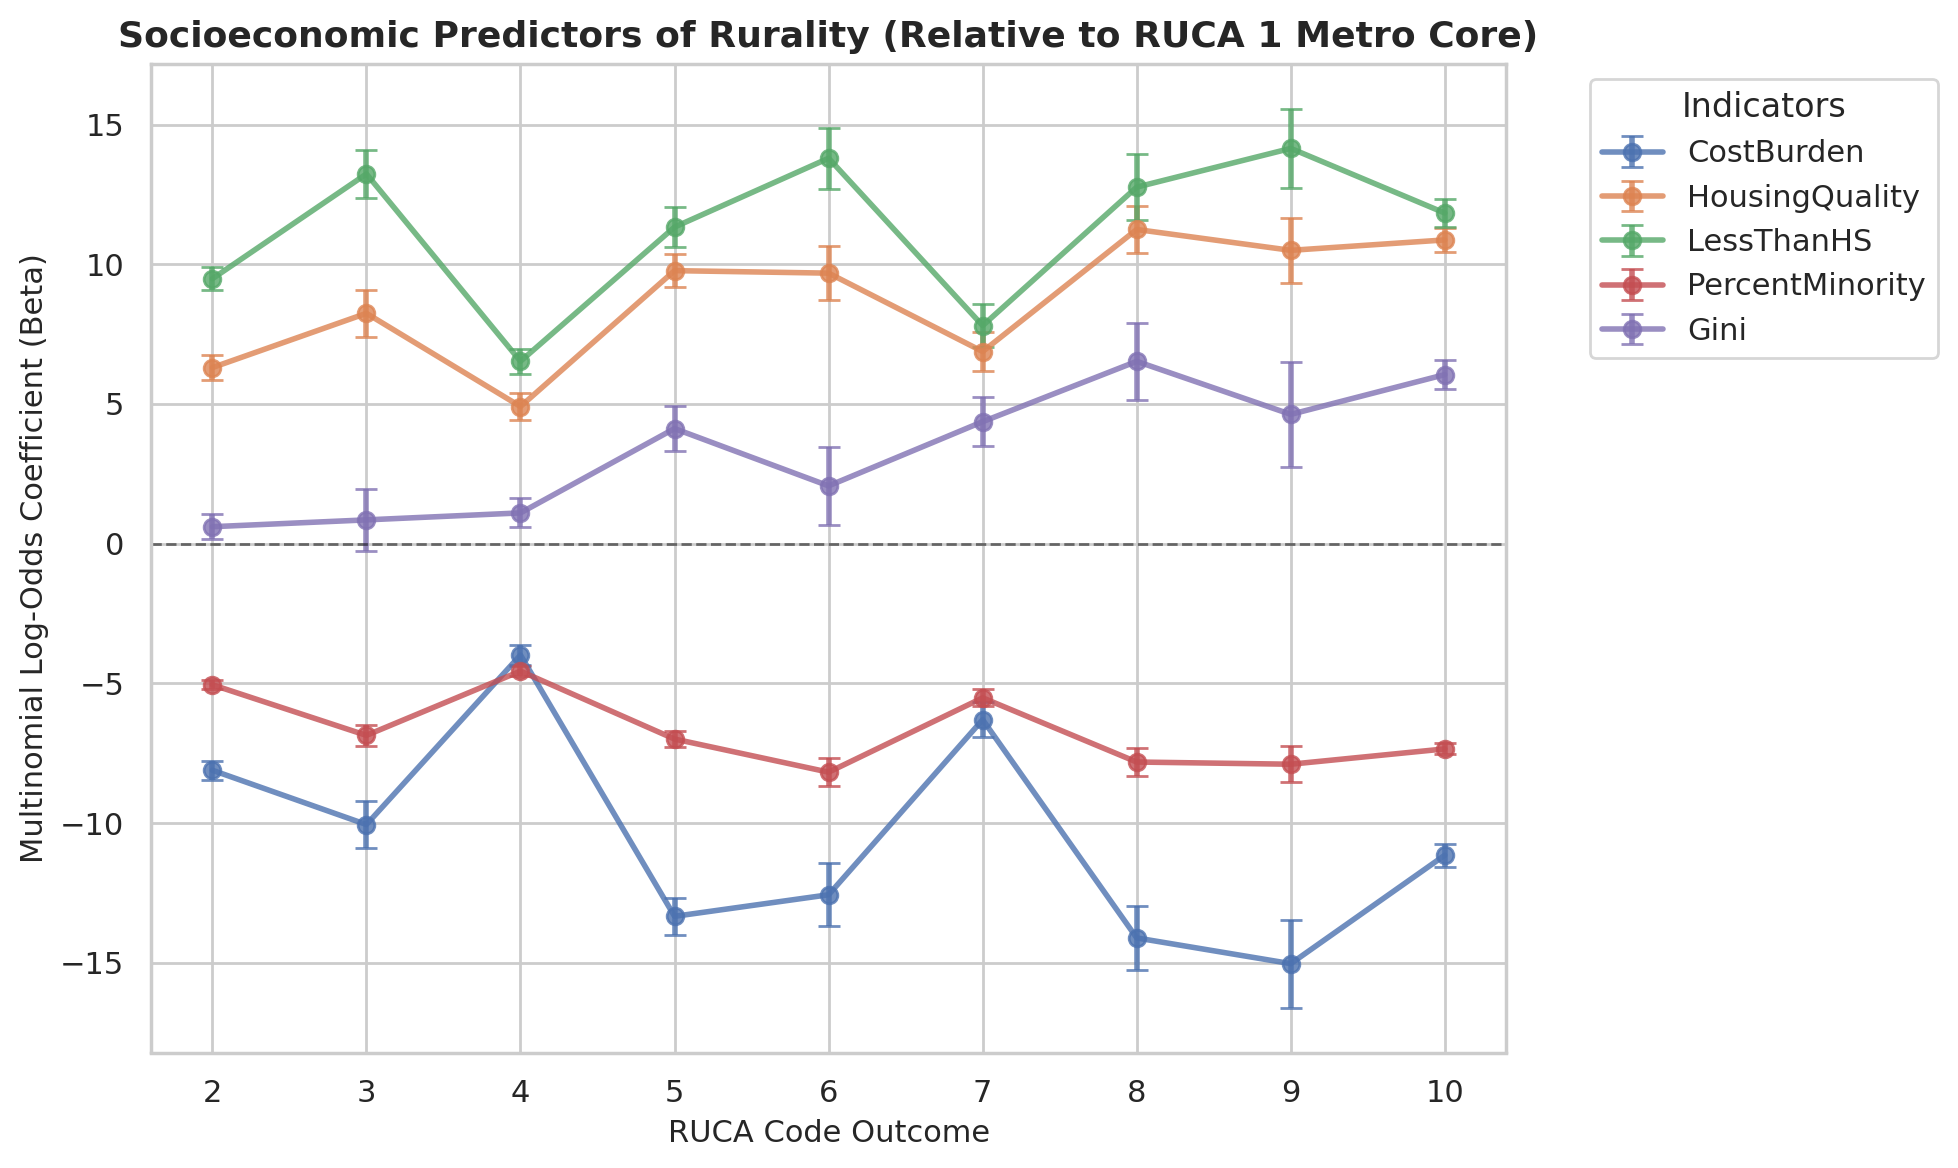

In [23]:
# statsmodels MNLogit results provide parameters and conf_int per outcome
params = result.params  # DataFrame of shape (num_features, num_classes-1)
conf_int = result.conf_int()  # shape: (num_classes-1, num_features, 2)

features_of_interest = [
    "CostBurden",
    "HousingQuality",
    "LessThanHS",
    "PercentMinority",
    "Gini",
]
ruca_classes = list(range(2, 11))

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

for feature in features_of_interest:
    coef_vals = [params.loc[feature, c - 2] for c in ruca_classes]

    # Calculate confidence interval ranges (95% CI)
    lower_vals = [
        result.conf_int().loc[(str(c), feature), "lower"] for c in ruca_classes
    ]
    upper_vals = [
        result.conf_int().loc[(str(c), feature), "upper"] for c in ruca_classes
    ]
    yerr = [
        np.array(coef_vals) - np.array(lower_vals),
        np.array(upper_vals) - np.array(coef_vals),
    ]

    ax.errorbar(
        ruca_classes,
        coef_vals,
        yerr=yerr,
        label=feature,
        fmt="-o",
        capsize=4,
        alpha=0.8,
        linewidth=2,
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title(
    "Socioeconomic Predictors of Rurality (Relative to RUCA 1 Metro Core)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("RUCA Code Outcome", fontsize=11)
ax.set_ylabel("Multinomial Log-Odds Coefficient (Beta)", fontsize=11)
ax.set_xticks(ruca_classes)
ax.legend(title="Indicators", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("mlr_coefficient_trajectories.png", bbox_inches="tight")
plt.show()


Positive multinomial log-odds coefficient: variable increase -> likelihood of class (RUCA code) increases.


In [24]:
# Predict probabilities of classification on the training data
probs = result.predict(X)

# Extract correct classification probability for each tract
df["RucaProb"] = probs.values[np.arange(len(y)), y - 1]

# Display summary statistics of the correct classification probabilities
print(
    "Mean probability of correct classification:", round(df["RucaProb"].mean() * 100, 2)
)
print("Median probability of correct classification:", np.median(df["RucaProb"]))


Mean probability of correct classification: 59.81
Median probability of correct classification: 0.7298630414056722


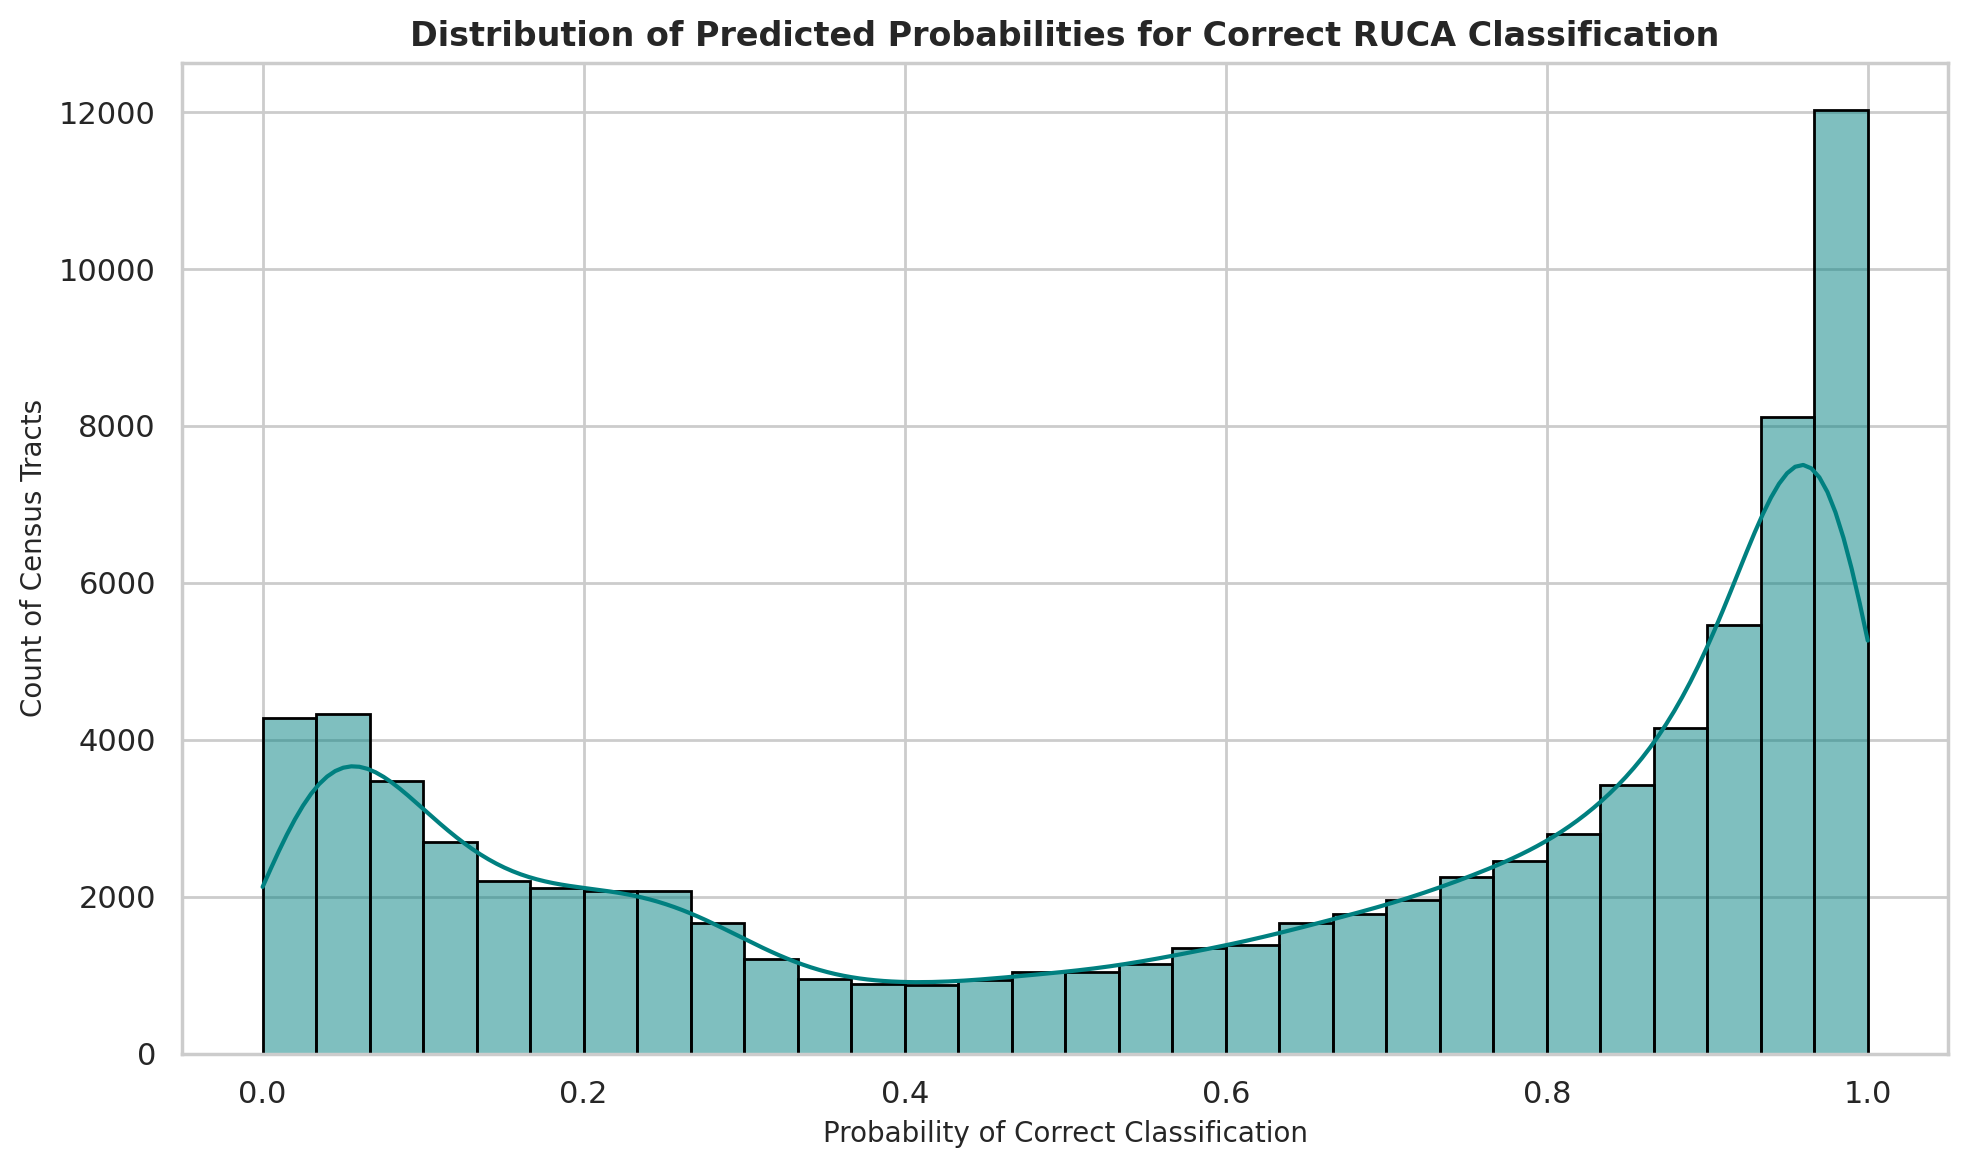

In [25]:
plt.figure(figsize=(10, 6), dpi=200)
sns.histplot(df["RucaProb"], bins=30, kde=True, color="teal", edgecolor="black")
plt.title(
    "Distribution of Predicted Probabilities for Correct RUCA Classification",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Probability of Correct Classification", fontsize=10)
plt.ylabel("Count of Census Tracts", fontsize=10)
plt.tight_layout()
plt.show()


It's certainly one of the distributions ever made.

In [ ]:
# !quarto render "Data Exploration.ipynb" --to gfm


pandoc 
  to: >-
    commonmark+autolink_bare_uris+emoji+footnotes+gfm_auto_identifiers+pipe_tables+strikeout+task_lists+tex_math_dollars-raw_html
  output-file: Data Exploration.md
  standalone: true
  default-image-extension: png
  toc: false
  number-sections: false
  wrap: none
  html-math-method: mathjax
  variables: {}
  
metadata
  engines:
    - path: /home/thotsky/opt/quarto-1.9.37/share/extension-subtrees/julia-engine/_extensions/julia-engine/julia-engine.js
  title: Rural Detention
  number-depth: 2
  toc-location: left
  jupyter: python3
  keep-yaml: true
  
Output created: Data Exploration.md

